# Advanced Exploratory Data Analysis (EDA_2)

Continuing from the basic EDA, here we dive deeper into correlations, categorical analysis, and relationships with the target.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/Train.csv')
print('Data loaded for advanced EDA')

Data loaded for advanced EDA


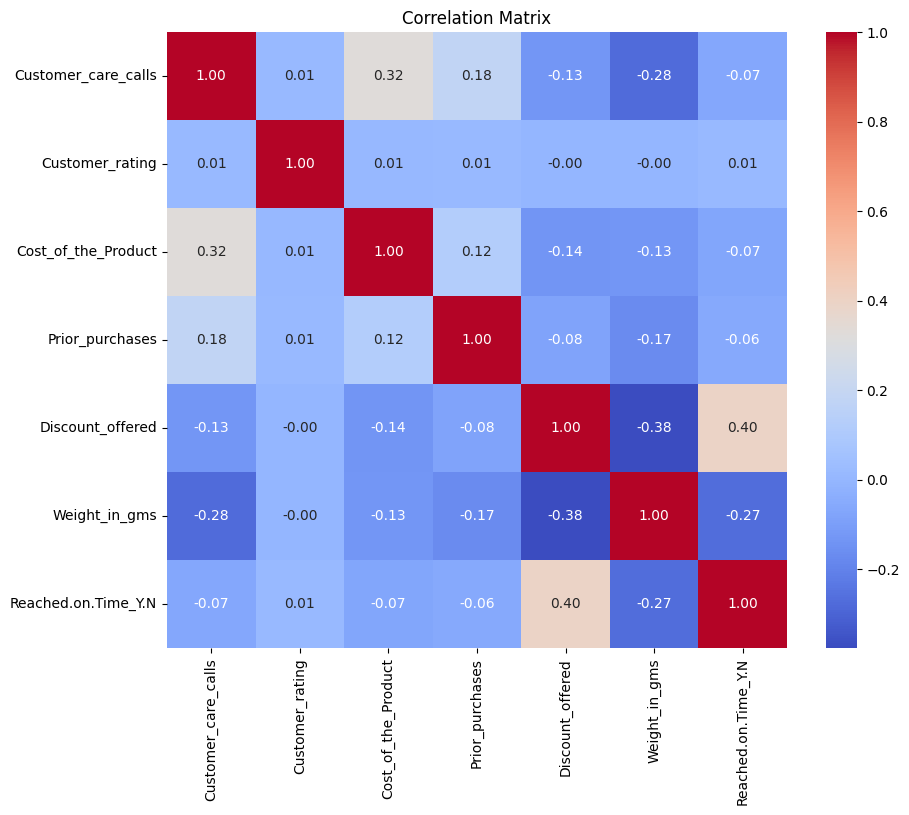

In [2]:
# Correlation matrix
numerical_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


Value counts for Warehouse_block:
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


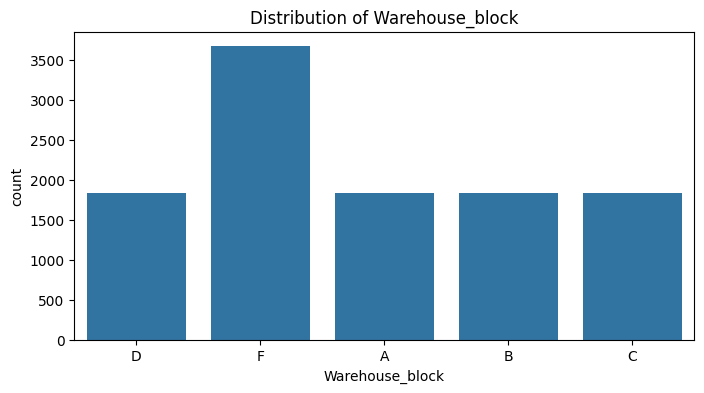


Value counts for Mode_of_Shipment:
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64


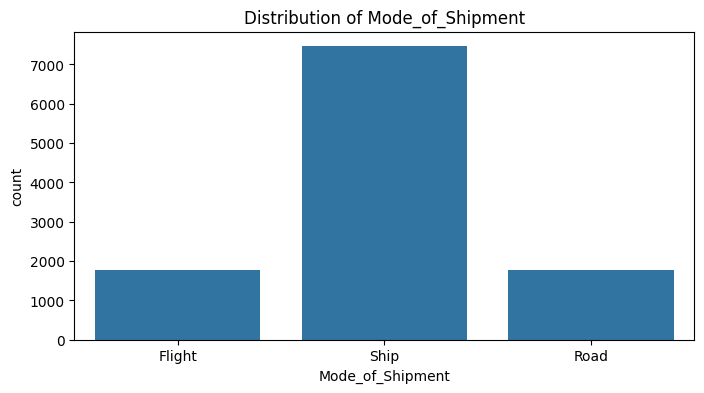


Value counts for Product_importance:
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64


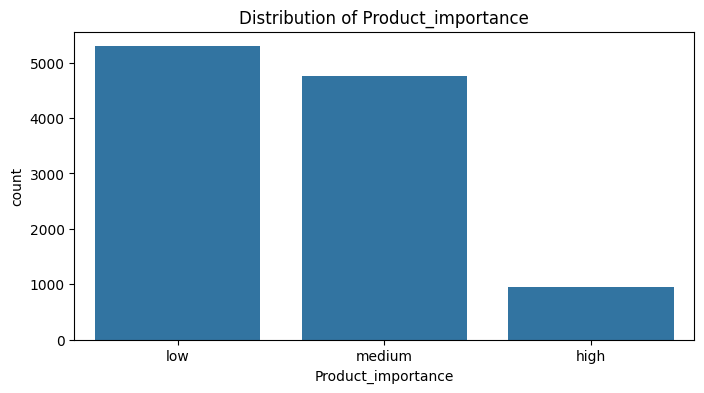


Value counts for Gender:
Gender
F    5545
M    5454
Name: count, dtype: int64


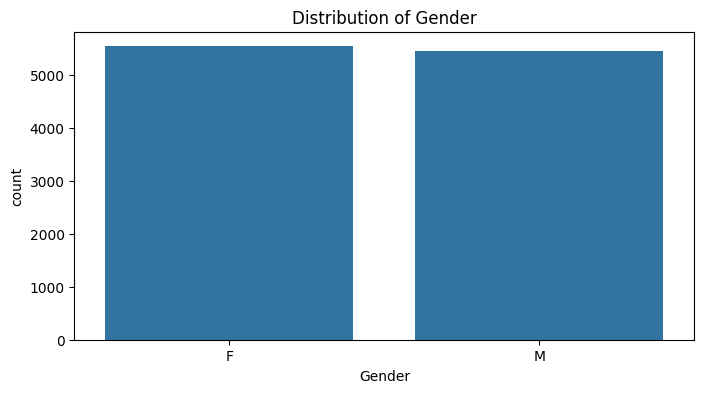

In [3]:
# Categorical columns analysis
categorical_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
for col in categorical_cols:
    print(f'\nValue counts for {col}:')
    print(df[col].value_counts())
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

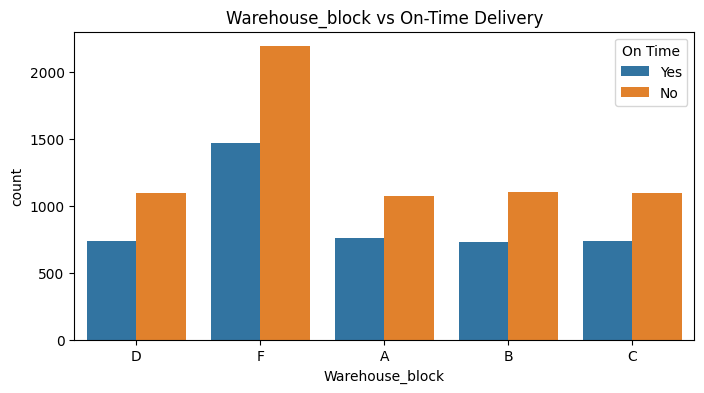

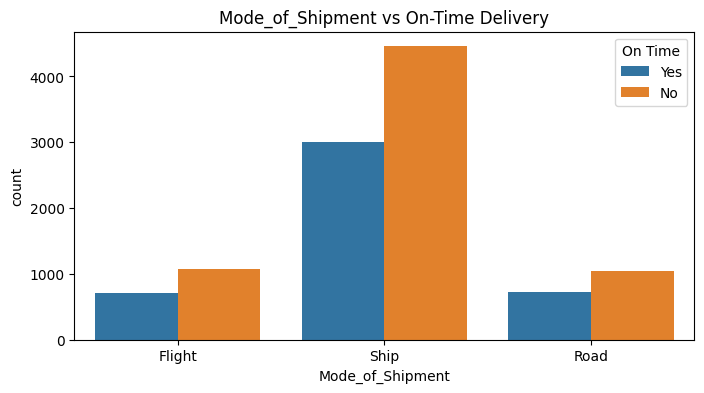

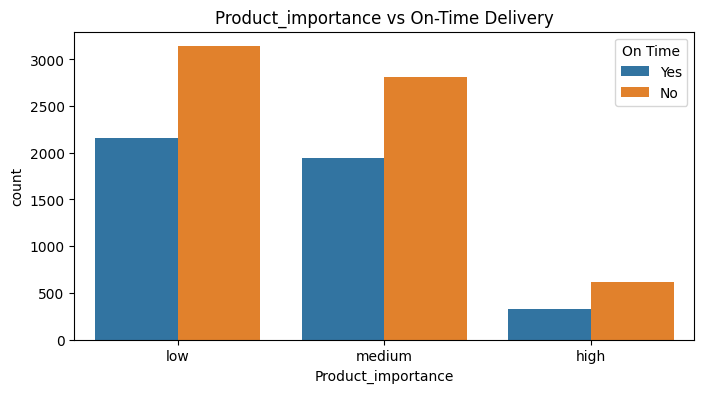

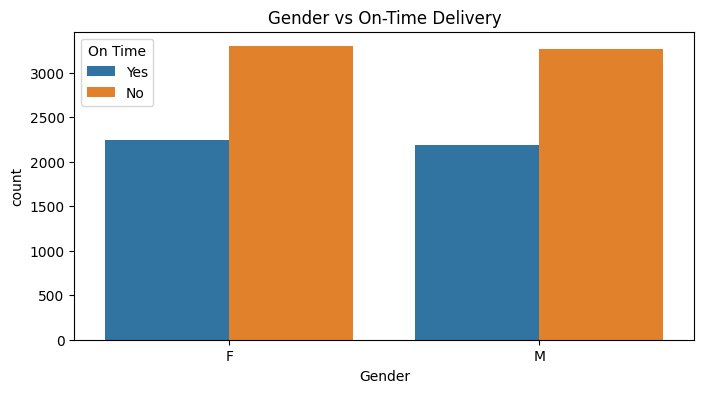

In [4]:
# Relationship between categorical variables and target
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Reached.on.Time_Y.N', data=df)
    plt.title(f'{col} vs On-Time Delivery')
    plt.legend(title='On Time', labels=['Yes', 'No'])
    plt.show()

Average cost by warehouse block:
Warehouse_block
A    208.767594
B    212.159302
C    211.191489
D    210.907852
F    209.077196
Name: Cost_of_the_Product, dtype: float64

On-time delivery rate by mode of shipment:
Mode_of_Shipment
Flight    0.601576
Road      0.588068
Ship      0.597561
Name: Reached.on.Time_Y.N, dtype: float64


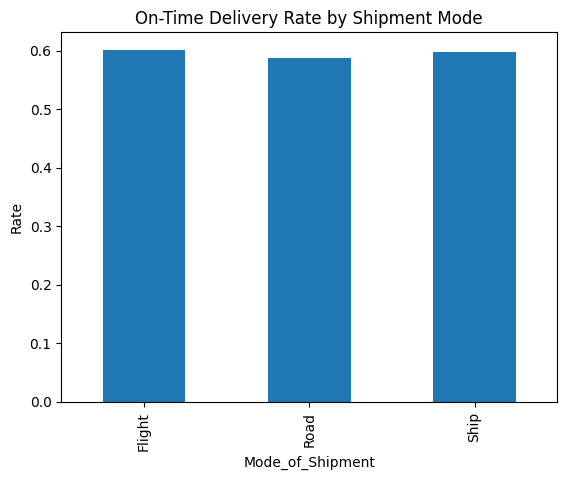

In [5]:
# Group by analysis
print('Average cost by warehouse block:')
print(df.groupby('Warehouse_block')['Cost_of_the_Product'].mean())

print('\nOn-time delivery rate by mode of shipment:')
ontime_rate = df.groupby('Mode_of_Shipment')['Reached.on.Time_Y.N'].mean()
print(ontime_rate)

ontime_rate.plot(kind='bar')
plt.title('On-Time Delivery Rate by Shipment Mode')
plt.ylabel('Rate')
plt.show()

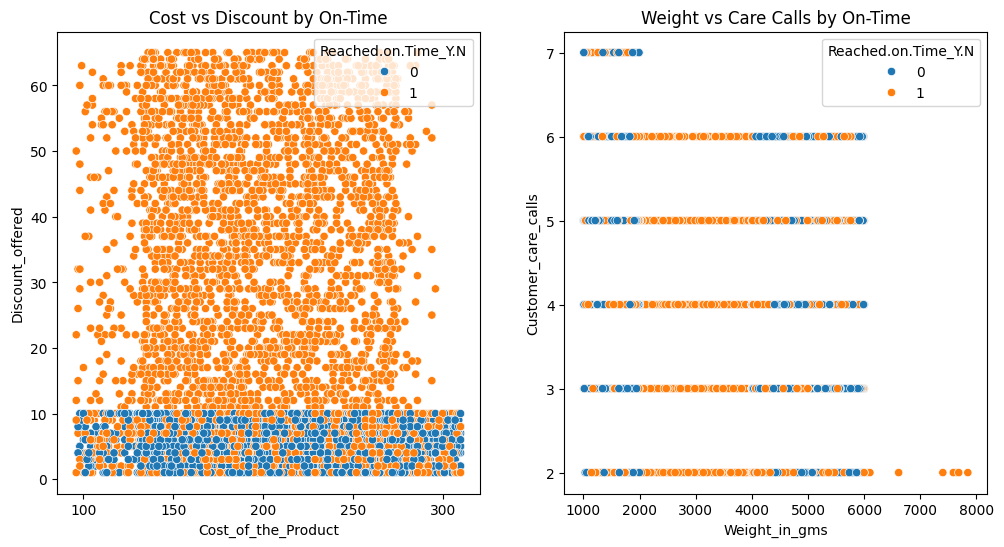

In [6]:
# Scatter plots for numerical vs target
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(x='Cost_of_the_Product', y='Discount_offered', hue='Reached.on.Time_Y.N', data=df)
plt.title('Cost vs Discount by On-Time')

plt.subplot(1,2,2)
sns.scatterplot(x='Weight_in_gms', y='Customer_care_calls', hue='Reached.on.Time_Y.N', data=df)
plt.title('Weight vs Care Calls by On-Time')
plt.show()